In [3]:
import tensorflow as tf
import tensorflow.keras as keras
import tensorflow.keras.layers as layers

import torch 
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder

import sklearn
from sklearn.model_selection import train_test_split

# import transformers
# import datasets
# import evaluate
# import accelerate

import numpy as np
import matplotlib.pyplot as plt

import PIL.Image as Image
import cv2
import pydicom

import sys 
import os
import time
import re
from pathlib import Path

from vnet import *
from utils import *
from patient import *

In [1]:
!which python

/home/wallace/anaconda3/envs/mlenv/bin/python


In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [4]:
device

device(type='cpu')

In [6]:
# Main roots
mask_root = "/mnt/HDD_1TB/Wallace/Segmentation_Raw/"
subdir1 = sorted(os.listdir(mask_root))

dicom_root = "/mnt/HDD_1TB/Wallace/Datasets/fibroid trial HIFU-SB-001/"
new_dicom_root = "/mnt/HDD_1TB/Wallace/Datasets/fibroid trial HIFU-SB-001/Siemens/"
old_dicom_root = "/mnt/HDD_1TB/Wallace/Datasets/fibroid trial HIFU-SB-001/Arrayus/"

In [7]:
bones = subdir1[0]
listbones = sorted(os.listdir(mask_root + bones))
siemens = subdir1[1]
listsiemens = sorted(os.listdir(mask_root + siemens))
lowres = subdir1[2]
listlowres = sorted(os.listdir(mask_root + lowres))
arrayus = subdir1[3]
listarrayus = sorted(os.listdir(mask_root + arrayus))

# I should probably reformat the files as this format is shitty

In [8]:
patient_19_root = os.path.join(mask_root + siemens, listsiemens[4])
patient_19_root

'/mnt/HDD_1TB/Wallace/Segmentation_Raw/Everything/19-41'

In [9]:
class Patient:
    def __init__(self, path, patient_num, sagittal_slices, coronal_slices) -> None:
        self.dir = sorted(os.listdir(path))
        self.mask_dir = os.path.join(path, self.dir[0])
        self.dicom_dir = os.path.join(path, self.dir[1])
        
        self.mask_listdir = sorted(os.listdir(self.mask_dir))   # ['Bowel', 'Catheter', 'Muscle', 'Skin', 'Spine', 'hip_L', 'hip_R']
        self.dicom_listdir = sorted(os.listdir(self.dicom_dir))
        
        self.coronal = os.path.join(self.dicom_dir, self.dicom_listdir[0])
        self.sagittal = os.path.join(self.dicom_dir, self.dicom_listdir[1])
        
        self.coronal_listdir = sorted(os.listdir(self.coronal))
        self.sagittal_listdir = sorted(os.listdir(self.sagittal))
        
        self.patient_num = patient_num
        
        self.colour_label = {'Spine': (35, 132, 250), 'Bowel': (14, 240, 56), 'Muscle': (214, 51, 36), 'Skin': (240, 170, 31), 'hip_L': (173, 20, 250), 'hip_R': (131, 20, 250)}
        
        self.sagittal_spacing = [0.9375, 0.9375]
        
        self.LPS = [sagittal_slices, coronal_slices, coronal_slices]
        
    def spine_seg(self):
        # Spine masks directory
        self.spine_dir = os.path.join(self.mask_dir, 'Spine')
        self.spine_listdir = sorted(os.listdir(self.spine_dir))
        
        # Start and end index of spine masks
        start = int(re.findall(r'\d+', self.spine_listdir[0])[0])
        end = int(re.findall(r'\d+', self.spine_listdir[-1])[0])
        
        # Spine masks and corresponding images' paths in lists
        self.spine_mask = [os.path.join(self.spine_dir, x) for x in self.spine_listdir]
        self.spine_img = [os.path.join(self.sagittal, x) for x in self.sagittal_listdir]
        
    def bowel_seg(self):
        # Bowel masks directory
        self.bowel_dir = os.path.join(self.mask_dir, 'Bowel')
        self.bowel_listdir = sorted(os.listdir(self.bowel_dir))
        
        # Start and end index of bowel masks
        start = int(re.findall(r'\d+', self.bowel_listdir[0])[0])
        end = int(re.findall(r'\d+', self.bowel_listdir[-1])[0])
        
        # Bowel masks and corresponding images' paths in lists
        self.bowel_mask = [os.path.join(self.bowel_dir, x) for x in self.bowel_listdir]
        self.bowel_img = [os.path.join(self.sagittal, x) for x in self.sagittal_listdir]
        
    def hipl_seg(self):
        # Left Hip masks directory
        self.hipl_dir = os.path.join(self.mask_dir, 'hip_L')
        self.hipl_listdir = sorted(os.listdir(self.hipl_dir))
        
        # Start and end index of hipl masks
        start = int(re.findall(r'\d+', self.hipl_listdir[0])[0])
        end = int(re.findall(r'\d+', self.hipl_listdir[-1])[0])
        
        # Left Hip masks and corresponding images' paths in lists
        self.hipl_mask = [os.path.join(self.hipl_dir, x) for x in self.hipl_listdir]
        self.hipl_img = [os.path.join(self.coronal, x) for x in self.coronal_listdir]
        
    def hipr_seg(self):
        # Right Hip masks directory
        self.hipr_dir = os.path.join(self.mask_dir, 'hip_R')
        self.hipr_listdir = sorted(os.listdir(self.hipr_dir))
        
        # Start and end index of hipr masks
        start = int(re.findall(r'\d+', self.hipr_listdir[0])[0])
        end = int(re.findall(r'\d+', self.hipr_listdir[-1])[0])
        
        # Right Hip masks and corresponding images' paths in lists
        self.hipr_mask = [os.path.join(self.hipr_dir, x) for x in self.hipr_listdir]
        self.hipr_img = [os.path.join(self.coronal, x) for x in self.coronal_listdir]
        
    def skin_seg(self):
        # Skin Fat masks directory
        self.skin_dir = os.path.join(self.mask_dir, 'Skin')
        self.skin_listdir = sorted(os.listdir(self.skin_dir))
        
        # Start and end index of skin masks
        start = int(re.findall(r'\d+', self.skin_listdir[0])[0])
        end = int(re.findall(r'\d+', self.skin_listdir[-1])[0])
        
        # Skin Fat masks and corresponding images' paths in lists
        self.skin_mask = [os.path.join(self.skin_dir, x) for x in self.skin_listdir]
        self.skin_img = [os.path.join(self.sagittal, x) for x in self.sagittal_listdir]
        
    def muscle_seg(self):
        # Muscle masks directory
        self.muscle_dir = os.path.join(self.mask_dir, 'Muscle')
        self.muscle_listdir = sorted(os.listdir(self.muscle_dir))
        
        # Start and end index of muscle masks
        start = int(re.findall(r'\d+', self.spine_listdir[0])[0])
        end = int(re.findall(r'\d+', self.spine_listdir[-1])[0])
        
        # Muscle masks and corresponding images' paths in lists
        self.muscle_mask = [os.path.join(self.muscle_dir, x) for x in self.muscle_listdir]
        self.muscle_img = [os.path.join(self.sagittal, x) for x in self.sagittal_listdir]

    
def stack3d(img_list, mask_list):
    # Stack the dicom images into 3D array
    img_value_list = [pydicom.dcmread(img).pixel_array for img in img_list]
    img_stack = np.stack(img_value_list, axis=0)
    img_stack = np.expand_dims(img_stack, axis=0)
        
    mask_value_list = [cv2.imread(mask, cv2.IMREAD_GRAYSCALE) for mask in mask_list]
    mask_stack = np.stack(mask_value_list, axis=0)
    mask_stack = np.expand_dims(mask_stack, axis=0)
    
    return img_stack, mask_stack

        

In [10]:
patient_19 = Patient(patient_19_root, 19, 140, 320)
patient_19.spine_seg()
patient_19.bowel_seg()
patient_19.hipl_seg()
patient_19.hipr_seg()
patient_19.skin_seg()
patient_19.muscle_seg()

example_dicom = patient_19.spine_img[70]
example_dicom = pydicom.dcmread(example_dicom)

exmaple_dicom2 = patient_19.hipr_img[20]
example_dicom2 = pydicom.dcmread(exmaple_dicom2)

spine_stack, spine_mask_stack = stack3d(patient_19.spine_img, patient_19.spine_mask)

In [11]:
# volume = (channel, depth, height, width)
spine_stack.shape, spine_mask_stack.shape 

((1, 144, 320, 320), (1, 144, 320, 320))

In [12]:
# Batch size = 1
spine_stack = np.expand_dims(spine_stack, axis=0)
spine_mask_stack = np.expand_dims(spine_mask_stack, axis=0)
print(spine_stack.shape, spine_mask_stack.shape)

(1, 1, 144, 320, 320) (1, 1, 144, 320, 320)


Text(0.5, 1.0, 'Overlay dicom and mask')

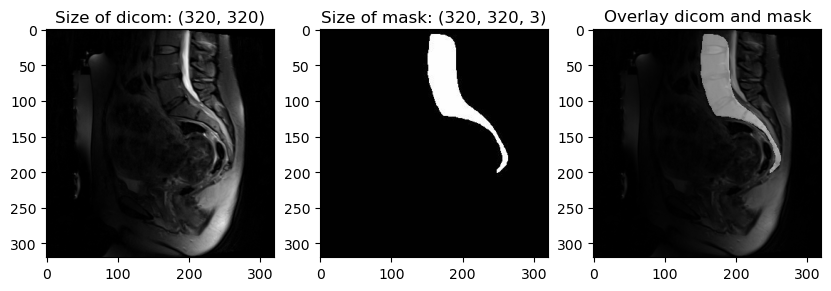

In [13]:
example_mask = cv2.imread(patient_19.spine_mask[70])

# Show mask on matplotlib
fig, ax = plt.subplots(1, 3, figsize=(10, 10))
ax[0].imshow(example_dicom.pixel_array, cmap='gray')
ax[0].set_title(f'Size of dicom: {example_dicom.pixel_array.shape}')
ax[1].imshow(example_mask, cmap='gray')
ax[1].set_title(f'Size of mask: {example_mask.shape}')

ax[2].imshow(example_dicom.pixel_array, cmap='gray')
ax[2].imshow(example_mask, cmap='jet', alpha=0.5)
ax[2].set_title('Overlay dicom and mask')

In [14]:
print(example_dicom.ImageOrientationPatient)    # Unit vector for P and S
print(example_dicom.ImagePositionPatient)   # X Y Z of L

[0.00000000, 1.00000000, 0.00000000, 0.00000000, 0.00000000, -1.00000000]
[12.25423717, -83.89830780, 149.86440678]


In [16]:
# from tqdm.auto import tqdm
from torch.utils.tensorboard import SummaryWriter

# writer = SummaryWriter()

EPOCH = 10
X = spine_stack
Y = spine_mask_stack

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X, y = torch.from_numpy(X.astype(np.float32)), torch.from_numpy(Y.astype(np.float32))
X, y = X.to(device), y.to(device)

results = {"train_loss": [], "train_acc": []}

model = VNet().to(device)
loss = DiceLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
#     writer.add_scalars(main_tag="Dice Loss", 
#                       tag_scalar_dict={"train_loss": train_loss},
#                       global_step=epoch)
#     writer.add_scalars(main_tag="Accuracy", 
#                         tag_scalar_dict={"train_acc": train_acc}, 
#                         global_step=epoch)

# writer.close()


In [17]:
print(X.shape, y.shape)

torch.Size([1, 1, 144, 320, 320]) torch.Size([1, 1, 144, 320, 320])


In [18]:
# My batch is 1 currently (just testing)
for epoch in range(EPOCH):
    
    try:
        y_logits = model(X)
        y_label = torch.argmax(y_logits, dim=1)
        y = flatten_mask(y)
        
        train_loss = loss(y_label, y)
        train_acc = accuracy(y_label, y)
        
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    except Exception as e:
        print(e)
        break

: 

: 

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 10))
ax[0].plot(results["train_loss"], label="train_loss")
ax[0].set_title("Dice Loss")
ax[1].plot(results["train_acc"], label="train_acc")
ax[1].set_title("Accuracy")

In [3]:
%matplotlib widget
import torch
import numpy as np
import matplotlib.pyplot as plt

def display_volume(logits, confidence):
    y_pred = torch.argmax(logits, dim=1)
    volume = y_pred.view(32, 32, 32)
    
    volume = volume.cpu().numpy()
    coords = np.nonzero(volume)
    
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(coords[0], coords[1], coords[2], c='b')
    ax.set_xlabel('X-axis')
    ax.set_ylabel('Y-axis')
    ax.set_zlabel('Z-axis')
    ax.set_title(f'Volumetric Mask | Confidence: {confidence:.1f}')
    plt.show()
    plt.clf()


In [ ]:
example_tensor = torch.randn(32768, 2)
display_volume(example_tensor, 0.5)

In [50]:
example_tensor = torch.Tensor([[0.2, 1.2] for _ in range(32768)])
example_tensor = torch.randn(32768, 2)
volume = ((torch.softmax(example_tensor, dim=1).argmax(dim=1)).view((32, 32, 32))).numpy()

In [48]:
volume.shape

(32, 32, 32)

In [ ]:
%matplotlib widget
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Generate coordinates for all voxels in the volume
x, y, z = np.indices(volume.shape)

# Flatten the volume and coordinates
x, y, z, volume = x.ravel(), y.ravel(), z.ravel(), volume.ravel()

# Create a mask for voxels with values above the threshold
mask = volume > 0.5

# Extract the coordinates and volume values for selected voxels
verts = [(x[i], y[i], z[i]) for i in range(len(volume)) if mask[i]]

# Create a Poly3DCollection object to represent the voxels
voxels = Poly3DCollection([verts], alpha=0.1, facecolors='red', edgecolors='red')

# Add the voxels to the subplot
ax.add_collection3d(voxels)

# Set plot attributes
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.set_title('3D Volume')

# Set plot limits
ax.set_xlim([0, 32])
ax.set_ylim([0, 32])
ax.set_zlim([0, 32])

# Show the plot
plt.show()

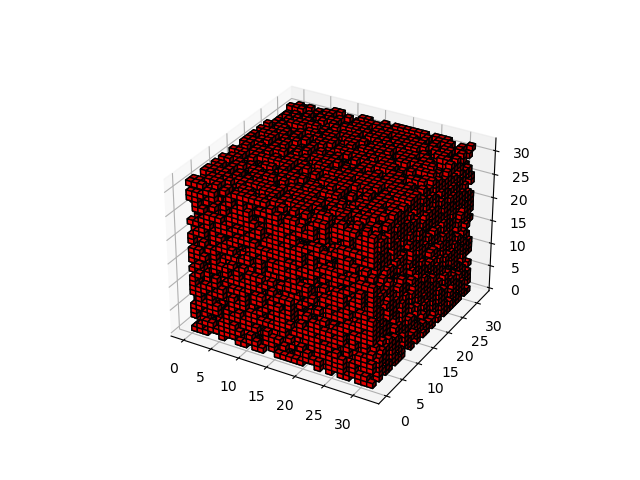

In [51]:
%matplotlib widget
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Generate coordinates for all voxels in the volume
x, y, z = np.indices(volume.shape)

# Create a mask for voxels with values above the threshold
mask = volume > 0.5
ax.voxels(mask, facecolors='red', edgecolor='k')
plt.show()

In [49]:
path = "content/ad/asdas/asdadss/19-01"
print((path.split("/")[-1]).split("-")[0])

19


In [ ]:
# Transfer Learning is Probably the best approach

In [ ]:
# KNN segmentation 


In [ ]:
# GMM segmentation

In [ ]:
# Unet segmentation 

In [ ]:
# SegFormer segmentation

In [ ]:
# SegNet segmentation (VGG)

In [ ]:
# BeiT 3 segmentation
from transformers import AutoImageProcessor, BeitModel
import torch

# Need to format the dataset into dictionary format
image_processor = AutoImageProcessor.from_pretrained('microsoft/beit-base-patch16-224-pt22k-ft22k')
model = BeitModel.from_pretrained('microsoft/beit-base-patch16-224-pt22k-ft22k')

In [ ]:
# Segment Anything Model (SAM) 

import torch
import torchvision

%%capture
!{sys.executable} -m pip install opencv-python matplotlib onnx onnxruntime
!{sys.executable} -m pip install 'git+https://github.com/facebookresearch/segment-anything.git'

from segment_anything import SegmentAnything, sam_model_registry, SamPredictor, SamGenerator
from transformers import SamModel, SamProcessor

sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"

device = "cuda" if torch.cuda.is_available() else "cpu"

model = SamModel.from_pretrained("facebook/sam-vit-huge").to(device)
processor = SamProcessor.from_pretrained("facebook/sam-vit-huge")


predictor = SamPredictor(model)

In [ ]:
# Utilty functions
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)
    
def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   
    
def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))    
    
def show_points_on_image(raw_image, input_points, input_labels=None):
    plt.figure(figsize=(10,10))
    plt.imshow(raw_image)
    input_points = np.array(input_points)
    if input_labels is None:
      labels = np.ones_like(input_points[:, 0])
    else:
      labels = np.array(input_labels)
    show_points(input_points, labels, plt.gca())
    plt.axis('on')
    plt.show()

def show_points_and_boxes_on_image(raw_image, boxes, input_points, input_labels=None):
    plt.figure(figsize=(10,10))
    plt.imshow(raw_image)
    input_points = np.array(input_points)
    if input_labels is None:
      labels = np.ones_like(input_points[:, 0])
    else:
      labels = np.array(input_labels)
    show_points(input_points, labels, plt.gca())
    for box in boxes:
      show_box(box, plt.gca())
    plt.axis('on')
    plt.show()

def show_masks_on_image(raw_image, masks, scores):
    if len(masks.shape) == 4:
      masks = masks.squeeze()
    if scores.shape[0] == 1:
      scores = scores.squeeze()

    nb_predictions = scores.shape[-1]
    fig, axes = plt.subplots(1, nb_predictions, figsize=(15, 15))

    for i, (mask, score) in enumerate(zip(masks, scores)):
      mask = mask.cpu().detach()
      axes[i].imshow(np.array(raw_image))
      show_mask(mask, axes[i])
      axes[i].title.set_text(f"Mask {i+1}, Score: {score.item():.3f}")
      axes[i].axis("off")
    plt.show()

In [ ]:
# DeepLabV3+ segmentation
import torch
model = torch.hub.load('pytorch/vision:v0.10.0', 'deeplabv3_resnet50', pretrained=True)